Loading Data...
Optimizing on 3672 cars...

Running Randomized Search (This effectively trains 20+ models to find the best one)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ BEST PARAMETERS FOUND: {'regressor__n_estimators': 300, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_depth': None}

--- FINAL EXAM ---
Training Accuracy: 99.64% (Lower is okay, means less memorization)
Testing Accuracy:  97.18% (Higher is better)
Gap (Overfitting): 2.46% (Target: < 5%)
Average Error: +/- PKR 245,358

Saved 'consistency_check.png'. If points hug the red line, it's consistent.
Saved optimized model to price_model_optimized.pkl


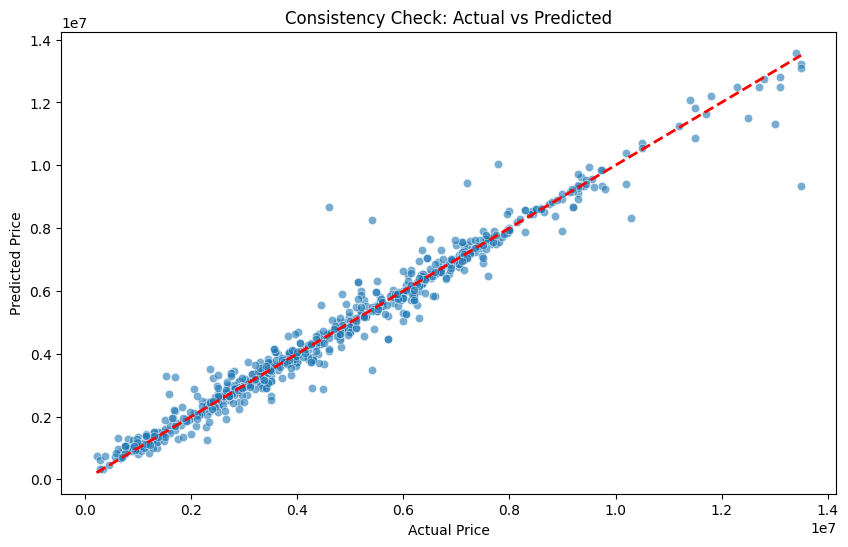

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# --- 1. SETUP & LOADING ---
INPUT_FILE = "../data/MASTER_CAR_DATASET.csv"
MODEL_FILE = "../models/price_model_optimized.pkl"

print("Loading Data...")
df = pd.read_csv(INPUT_FILE)

# Column Fix (Just in case)
if 'price_cleaned' in df.columns:
    df['price'] = df['price_cleaned'].combine_first(df['price'])
    df['mileage'] = df['mileage_cleaned'].combine_first(df['mileage'])
    df['engine'] = df['engine_cleaned'].combine_first(df['engine'])

# Filter Data (Remove extreme outliers that confuse the model)
df = df.dropna(subset=['price', 'model_year', 'mileage', 'engine'])
df = df[df['price'] < 15000000] # Cap at 1.5 Crore (Focus on mass market)
df = df[df['mileage'] < 300000]

# Features
X = df[['title_version', 'model_year', 'mileage', 'engine', 'transmission', 'fuel', 'inspection_score']]
y = df['price']

print(f"Optimizing on {len(df)} cars...")

# --- 2. BUILD THE PIPELINE ---
preprocessor = ColumnTransformer(
    transformers=[
        ('title', TfidfVectorizer(max_features=100, stop_words='english'), 'title_version'),
        ('cats', OneHotEncoder(handle_unknown='ignore'), ['transmission', 'fuel']),
    ],
    remainder='passthrough'
)

# We use a base model, but we will TUNE it below
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# --- 3. HYPERPARAMETER TUNING (The "Testing" Phase) ---
# We try different settings to find the most stable one.
# 'max_depth': Limits how deep the tree grows (Prevents memorization)
# 'min_samples_leaf': Forces trees to not look at tiny groups of 1-2 cars

param_dist = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [10, 20, 30, None],  # None = Infinite depth (Overfitting risk)
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]     # Higher number = More smoothing
}

print("\nRunning Randomized Search (This effectively trains 20+ models to find the best one)...")
# cv=5 means "5-Fold Cross Validation" (Tests every car 5 times)
search = RandomizedSearchCV(model_pipeline, param_dist, n_iter=10, cv=3, scoring='r2', n_jobs=-1, verbose=1, random_state=42)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Run the Search
search.fit(X_train, y_train)

best_model = search.best_estimator_
print(f"\n✅ BEST PARAMETERS FOUND: {search.best_params_}")

# --- 4. RIGOROUS EVALUATION ---
print("\n--- FINAL EXAM ---")
train_preds = best_model.predict(X_train)
test_preds = best_model.predict(X_test)

r2_train = r2_score(y_train, train_preds)
r2_test = r2_score(y_test, test_preds)
mae = mean_absolute_error(y_test, test_preds)

print(f"Training Accuracy: {r2_train:.2%} (Lower is okay, means less memorization)")
print(f"Testing Accuracy:  {r2_test:.2%} (Higher is better)")
print(f"Gap (Overfitting): {r2_train - r2_test:.2%} (Target: < 5%)")
print(f"Average Error: +/- PKR {int(mae):,}")

# --- 5. VISUAL PROOF (The Consistency Check) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=test_preds, alpha=0.6)
# Draw the "Perfect Line"
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Consistency Check: Actual vs Predicted")
plt.savefig("../assets/consistency_check.png")
print("\nSaved 'consistency_check.png'. If points hug the red line, it's consistent.")

# --- 6. SAVE THE PERFECT BRAIN ---
joblib.dump(best_model, MODEL_FILE)
print(f"Saved optimized model to {MODEL_FILE}")

Loading Data...
Comparing on 3672 cars...

Model                        | R2 Score   | MAE             | RMSE           
-------------------------------------------------------------------------------------
Linear Regression            | 0.8148     | 784649.00       | 1135799.68     
Random Forest                | 0.9714     | 246475.37       | 446273.42      
XGBoost                      | 0.9661     | 252441.35       | 485707.15      
Tuned Random Forest (Final)  | 0.9718     | 245358.43       | 442860.05      

Final Comparison Table:
                         Model  R2 Score            MAE          RMSE
0            Linear Regression  0.814777  784649.002729  1.135800e+06
1                Random Forest  0.971405  246475.369291  4.462734e+05
2                      XGBoost  0.966128  252441.354294  4.857072e+05
3  Tuned Random Forest (Final)  0.971840  245358.429543  4.428601e+05


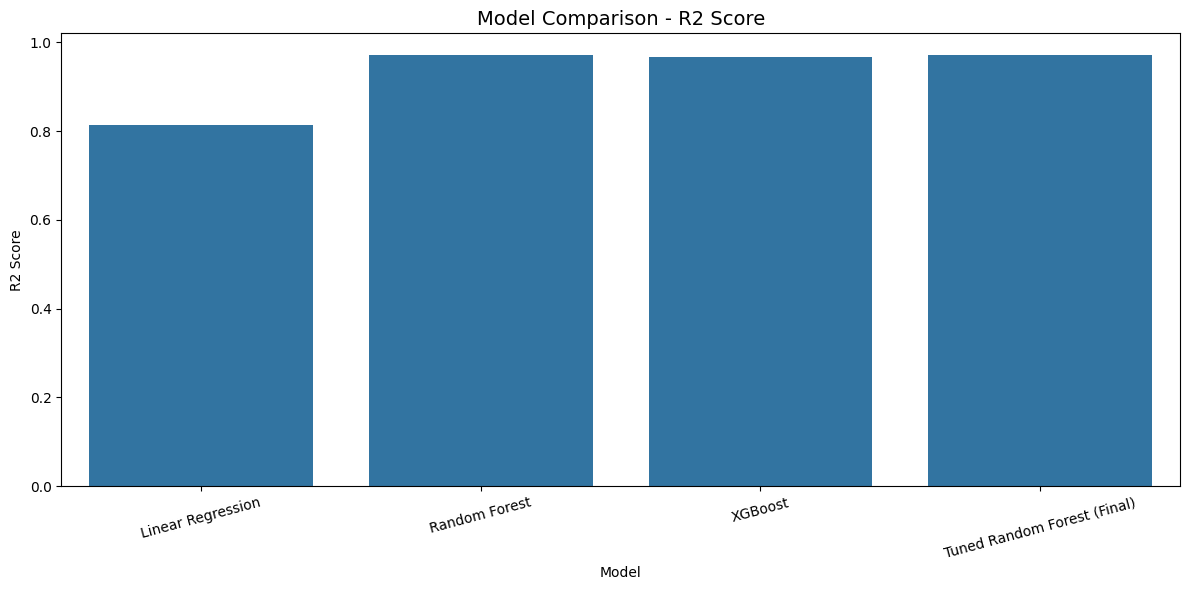

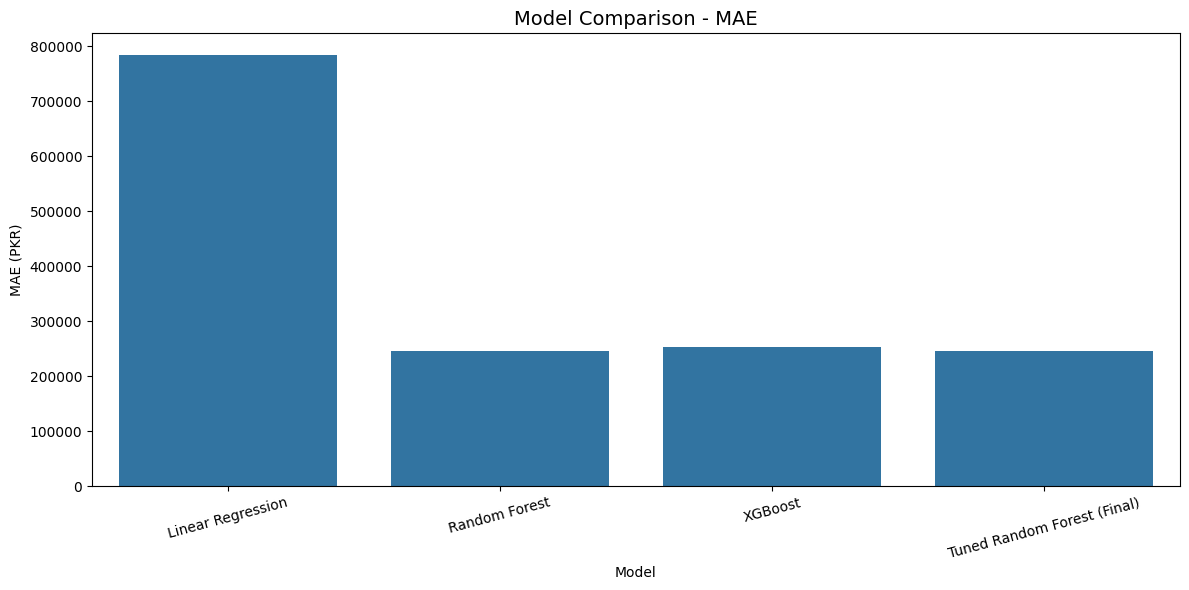

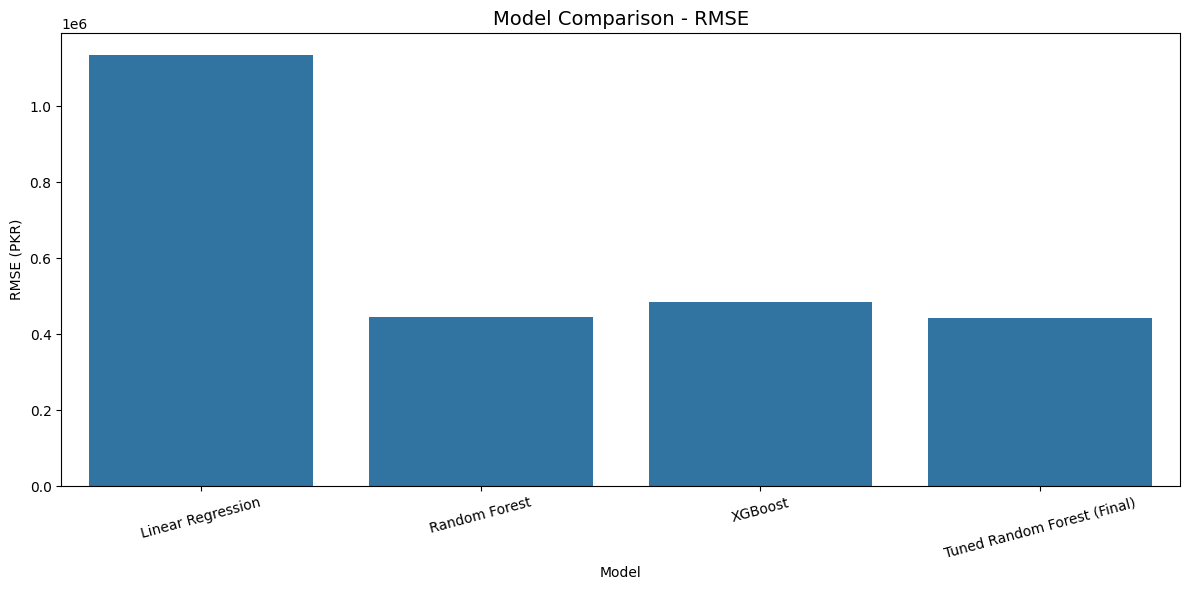

In [7]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from pathlib import Path

# --- 1. LOAD & CLEAN DATA (SAME AS TUNED RF SCRIPT) ---
INPUT_FILE = "../data/MASTER_CAR_DATASET.csv"
TUNED_MODEL_FILE = "../models/price_model_optimized.pkl"

print("Loading Data...")
df = pd.read_csv(INPUT_FILE)

# Column Fix
if 'price_cleaned' in df.columns:
    df['price'] = df['price_cleaned'].combine_first(df['price'])
    df['mileage'] = df['mileage_cleaned'].combine_first(df['mileage'])
    df['engine'] = df['engine_cleaned'].combine_first(df['engine'])

# Same filtering as tuned RF
df = df.dropna(subset=['price', 'model_year', 'mileage', 'engine'])
df = df[df['price'] < 15000000]   # Cap at 1.5 Crore
df = df[df['mileage'] < 300000]

# Features
X = df[['title_version', 'model_year', 'mileage', 'engine',
        'transmission', 'fuel', 'inspection_score']]
y = df['price']

print(f"Comparing on {len(df)} cars...")

# --- 2. TRAIN/TEST SPLIT (SAME AS TUNED RF SCRIPT) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 3. PREPROCESSOR (SAME FEATURE ENGINEERING) ---
preprocessor = ColumnTransformer(
    transformers=[
        ('title', TfidfVectorizer(max_features=100, stop_words='english'), 'title_version'),
        ('cats', OneHotEncoder(handle_unknown='ignore'), ['transmission', 'fuel']),
    ],
    remainder='passthrough'
)

# --- 4. BASELINE MODELS ---
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42,
        objective='reg:squarederror'
    )
}

# --- 5. LOAD TUNED RF PIPELINE ---
tuned_rf_pipeline = joblib.load(TUNED_MODEL_FILE)

# --- 6. RESULTS STORAGE ---
results = []
assets_folder = Path("../assets")
assets_folder.mkdir(parents=True, exist_ok=True)

print(f"\n{'Model':<28} | {'R2 Score':<10} | {'MAE':<15} | {'RMSE':<15}")
print("-" * 85)

# --- 7. EVALUATE BASELINE MODELS ---
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"{name:<28} | {r2:<10.4f} | {mae:<15.2f} | {rmse:<15.2f}")

    # Consistency Check (Actual vs Predicted)
    plt.figure(figsize=(12, 6))
    sns.scatterplot(x=y_test, y=preds, alpha=0.6)
    # Draw the "Perfect Line"
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"Consistency Check - {name}: Actual vs Predicted")
    plt.savefig(assets_folder / f"consistency_check_{name.replace(' ', '_')}.png")
    plt.close()

# --- 8. EVALUATE TUNED RANDOM FOREST (.pkl) ---
tuned_preds = tuned_rf_pipeline.predict(X_test)

tuned_r2 = r2_score(y_test, tuned_preds)
tuned_mae = mean_absolute_error(y_test, tuned_preds)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))

results.append({
    "Model": "Tuned Random Forest (Final)",
    "R2 Score": tuned_r2,
    "MAE": tuned_mae,
    "RMSE": tuned_rmse
})

print(f"{'Tuned Random Forest (Final)':<28} | {tuned_r2:<10.4f} | {tuned_mae:<15.2f} | {tuned_rmse:<15.2f}")

# Consistency Check (Actual vs Predicted)
plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_test, y=tuned_preds, alpha=0.6)
# Draw the "Perfect Line"
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Consistency Check - Tuned Random Forest (Final): Actual vs Predicted")
plt.savefig(assets_folder / f"consistency_check_Tuned_Random_Forest_(Final).png")
plt.close()

# --- 9. FINAL COMPARISON TABLE ---
results_df = pd.DataFrame(results)

print("\nFinal Comparison Table:")
print(results_df)

# Save table as CSV
results_df.to_csv(assets_folder / "final_model_comparison.csv", index=False)

# --- 10. GRAPHS N BAR CHARTS ---

# R2
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Model", y="R2 Score")
plt.title("Model Comparison - R2 Score", fontsize=14)
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(assets_folder / "final_comparison_r2.png", dpi=300, bbox_inches='tight')
plt.show()

# MAE
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Model", y="MAE")
plt.title("Model Comparison - MAE", fontsize=14)
plt.ylabel("MAE (PKR)")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(assets_folder / "final_comparison_mae.png", dpi=300, bbox_inches='tight')
plt.show()

# RMSE
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model Comparison - RMSE", fontsize=14)
plt.ylabel("RMSE (PKR)")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(assets_folder / "final_comparison_rmse.png", dpi=300, bbox_inches='tight')
plt.show()